# Analiza porażek i trade-offy

Towarzysz `solution.ipynb`. Główny wynik tam jest taki: **najprostszy model (XGBoost na surowych cechach, bez FE) wygrywa po skalibrowaniu progu**. Ten notebook tłumaczy dlaczego tak się dzieje, gdzie każdy model zawodzi i jak operator widzi trade-offy.

Struktura:

1. Re-budowa czterech pipeline'ów scoringu, żeby ta analiza była samodzielna.
2. Krzywe precision-recall dla każdego (metoda × fold) — pokazują osiągalne punkty pracy.
3. Wykresy rozkładów prawdopodobieństw — tłumaczą dlaczego domyślny próg 0.5 załamuje się na `altitude_spoof`.
4. Anatomia failure case'u — dlaczego modele FE-heavy przegrywają na `altitude_spoof`.
5. Ograniczenia i trade-offy.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (precision_recall_curve, f1_score,
                             precision_score, recall_score, average_precision_score,
                             confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [28]:
# --- Re-budowa czterech pipeline'ow dokladnie jak w solution.ipynb -------
df = pd.read_csv('honeywell_gold_dataset.csv')

CONST_DROP = [
    'delta_q_reset[0]','delta_q_reset[1]','delta_q_reset[2]','delta_q_reset[3]',
    'quat_reset_counter','delta_alt','lat_lon_reset_counter','alt_reset_counter',
    'dead_reckoning','time_utc_usec','timestamp_time_relative','heading_offset',
    'fix_type','vel_ned_valid','ref_lat','ref_lon','ref_alt',
    'delta_xy[0]','delta_xy[1]','delta_z',
    'delta_vxy[0]','delta_vxy[1]','delta_vz','delta_heading',
    'xy_valid','z_valid','v_xy_valid','v_z_valid',
    'xy_reset_counter','z_reset_counter','vxy_reset_counter','vz_reset_counter',
    'heading_reset_counter','xy_global','z_global',
]
def prepare(df):
    df = df.copy()
    df['lat_y']           = df['lat_y'] / 1e7
    df['lon_y']           = df['lon_y'] / 1e7
    df['alt_y']           = df['alt_y'] / 1000.0
    df['alt_ellipsoid_y'] = df['alt_ellipsoid_y'] / 1000.0
    df = df.drop(columns=[c for c in CONST_DROP if c in df.columns])
    df = df.drop(columns=['timestamp'])
    return df

def add_divergence_features(df):
    df = df.copy()
    cos_lat = np.cos(np.radians(df['lat_x']))
    df['lat_diff_m']      = (df['lat_x'] - df['lat_y']) * 111_000.0
    df['lon_diff_m']      = (df['lon_x'] - df['lon_y']) * 111_000.0 * cos_lat
    df['alt_diff_m']      =  df['alt_x'] - df['alt_y']
    df['alt_ell_diff_m']  =  df['alt_ellipsoid_x'] - df['alt_ellipsoid_y']
    df['pos_diff_h_m']    = np.sqrt(df['lat_diff_m']**2 + df['lon_diff_m']**2)
    df['pos_diff_3d_m']   = np.sqrt(df['pos_diff_h_m']**2 + df['alt_diff_m']**2)
    df['abs_lat_diff_m']  = df['lat_diff_m'].abs()
    df['abs_lon_diff_m']  = df['lon_diff_m'].abs()
    df['abs_alt_diff_m']  = df['alt_diff_m'].abs()
    df['vn_diff'] = df['vx'] - df['vel_n_m_s']
    df['ve_diff'] = df['vy'] - df['vel_e_m_s']
    df['vd_diff'] = df['vz'] - df['vel_d_m_s']
    df['vel_diff_h']  = np.sqrt(df['vn_diff']**2 + df['ve_diff']**2)
    df['vel_diff_3d'] = np.sqrt(df['vel_diff_h']**2 + df['vd_diff']**2)
    df['speed_local']   = np.sqrt(df['vx']**2 + df['vy']**2 + df['vz']**2)
    df['speed_h_local'] = np.sqrt(df['vx']**2 + df['vy']**2)
    df['speed_diff']    = df['speed_local'] - df['vel_m_s']
    cog_local = np.arctan2(df['vy'], df['vx'])
    df['cog_diff'] = (df['cog_rad'] - cog_local + np.pi) % (2*np.pi) - np.pi
    df['abs_cog_diff'] = df['cog_diff'].abs()
    return df

ROLL_BASE = [
    'lat_diff_m','lon_diff_m','alt_diff_m',
    'pos_diff_h_m','pos_diff_3d_m',
    'vn_diff','ve_diff','vd_diff','vel_diff_h','vel_diff_3d',
    'speed_diff','abs_cog_diff',
    'eph_y','epv_y','s_variance_m_s','c_variance_rad',
    'eph','epv','evh','evv','ax','ay','az',
]
WINDOWS = [10, 50, 200]
def add_rolling_features(df):
    out = df.copy()
    for w in WINDOWS:
        rolled = (df[ROLL_BASE]
                    .rolling(w, min_periods=1).agg(['mean','std']))
        rolled.columns = [f'{c}_r{w}_{stat}' for c, stat in rolled.columns]
        out = pd.concat([out, rolled], axis=1)
    return out.fillna(0.0)

raw_data = prepare(df)
fe_data  = add_rolling_features(add_divergence_features(raw_data))

RAW_FEATS = [c for c in raw_data.columns if c not in ('label',)]
FE_FEATS  = [c for c in fe_data.columns  if c not in ('label',)]
print('cech surowych:', len(RAW_FEATS), '   cech po FE:', len(FE_FEATS))


cech surowych: 47    cech po FE: 222


In [29]:
def supervised_cv(make_model, data, feats, n_splits=4):
    fold_proba = {}
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(data, data['label'])):
        tr = data.iloc[train_idx]
        te = data.iloc[test_idx]
        sc = StandardScaler().fit(tr[feats].values)
        m = make_model().fit(sc.transform(tr[feats].values), tr['label'].values)
        proba = m.predict_proba(sc.transform(te[feats].values))[:, 1]
        fold_proba[f'fold_{fold_idx}'] = (te['label'].values, proba)
    return fold_proba

def iforest_cv(data, feats, n_splits=4):
    fold_proba = {}
    clean = data[data['label'] == 0]
    sc = StandardScaler().fit(clean[feats].values)
    iforest = IsolationForest(n_estimators=200, contamination='auto',
                              random_state=42, n_jobs=-1).fit(sc.transform(clean[feats].values))
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(data, data['label'])):
        te = data.iloc[test_idx]
        score = -iforest.score_samples(sc.transform(te[feats].values))
        proba = (score - score.min()) / (score.max() - score.min() + 1e-12)
        fold_proba[f'fold_{fold_idx}'] = (te['label'].values, proba)
    return fold_proba

xgb_kw = dict(n_estimators=400, max_depth=6, learning_rate=0.05,
              subsample=0.85, colsample_bytree=0.85,
              eval_metric='logloss', random_state=42, n_jobs=-1)
lgb_kw = dict(n_estimators=600, learning_rate=0.04, num_leaves=63,
              min_child_samples=20, subsample=0.85, colsample_bytree=0.85,
              reg_alpha=0.1, reg_lambda=0.1, verbose=-1, random_state=42, n_jobs=-1)

base_proba = supervised_cv(lambda: XGBClassifier(**xgb_kw), raw_data, RAW_FEATS)
xgb_proba  = supervised_cv(lambda: XGBClassifier(**xgb_kw),  fe_data, FE_FEATS)
lgb_proba  = supervised_cv(lambda: LGBMClassifier(**lgb_kw), fe_data, FE_FEATS)
if_proba   = iforest_cv(fe_data, FE_FEATS)

METHODS = {
    'Baseline (raw, bez FE)':         base_proba,
    'XGBoost + FE':                   xgb_proba,
    'LightGBM + FE':                  lgb_proba,
    'IsolationForest (tylko czyste)': if_proba,
}

## Krzywe precision-recall

Każda krzywa pokazuje co jest osiągalne we wszystkich progach. Bliżej prawego górnego rogu = lepiej. Marker na każdej krzywej to punkt pracy przy skalibrowanym progu (wybranym z OOF na *pozostałych* foldach — bez przecieku z testu).

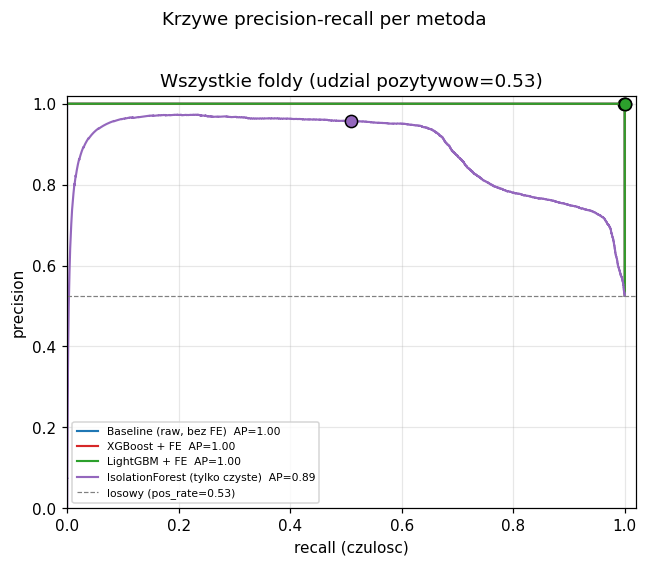

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
COLORS = {'Baseline (raw, bez FE)':'#1f77b4', 'XGBoost + FE':'#d62728',
          'LightGBM + FE':'#2ca02c', 'IsolationForest (tylko czyste)':'#9467bd'}

for name, fp in METHODS.items():
    # Zbieranie wynikow ze wszystkich foldow
    ys, ps = [], []
    for fold_name, (y, p) in fp.items():
        ys.extend(y); ps.extend(p)
    y, p = np.array(ys), np.array(ps)
    
    prec, rec, thr = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    ax.plot(rec, prec, color=COLORS[name], lw=1.4,
            label=f'{name}  AP={ap:.2f}')
    
    # punkt pracy
    pred = (p >= 0.5).astype(int)
    op_p = precision_score(y, pred, zero_division=0)
    op_r = recall_score(y, pred, zero_division=0)
    ax.plot(op_r, op_p, 'o', color=COLORS[name], ms=8, mec='black')

pos_rate = np.mean(y)
ax.axhline(pos_rate, color='gray', ls='--', lw=0.8,
           label=f'losowy (pos_rate={pos_rate:.2f})')
ax.set_title(f'Wszystkie foldy (udzial pozytywow={pos_rate:.2f})')
ax.set_xlabel('recall (czulosc)'); ax.set_ylabel('precision')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.legend(fontsize=7, loc='lower left')
plt.suptitle('Krzywe precision-recall per metoda', y=1.02)
plt.tight_layout()
plt.show()


## Rozkłady prawdopodobieństw per fold

Dlaczego domyślny próg 0.5 załamuje się na `altitude_spoof`: nadzorowane modele trenowane na *innych* typach ataków produkują prawdopodobieństwa ciasno skupione blisko 0 dla trzymanego foldu altitude — model nigdy nie widział relevantnego wzorca cech, więc pewnie mówi "czysto". Ranking jest nadal użyteczny (AUC > 0.5), ale *absolutne* prawdopodobieństwa są niekalibrowane dla tego rozkładu.

Poniżej: histogram prawdopodobieństw modelu dla trzymanego scenariusza, podzielony wg prawdziwej etykiety. Linie pionowe oznaczają domyślny próg 0.5 i próg skalibrowany OOF.

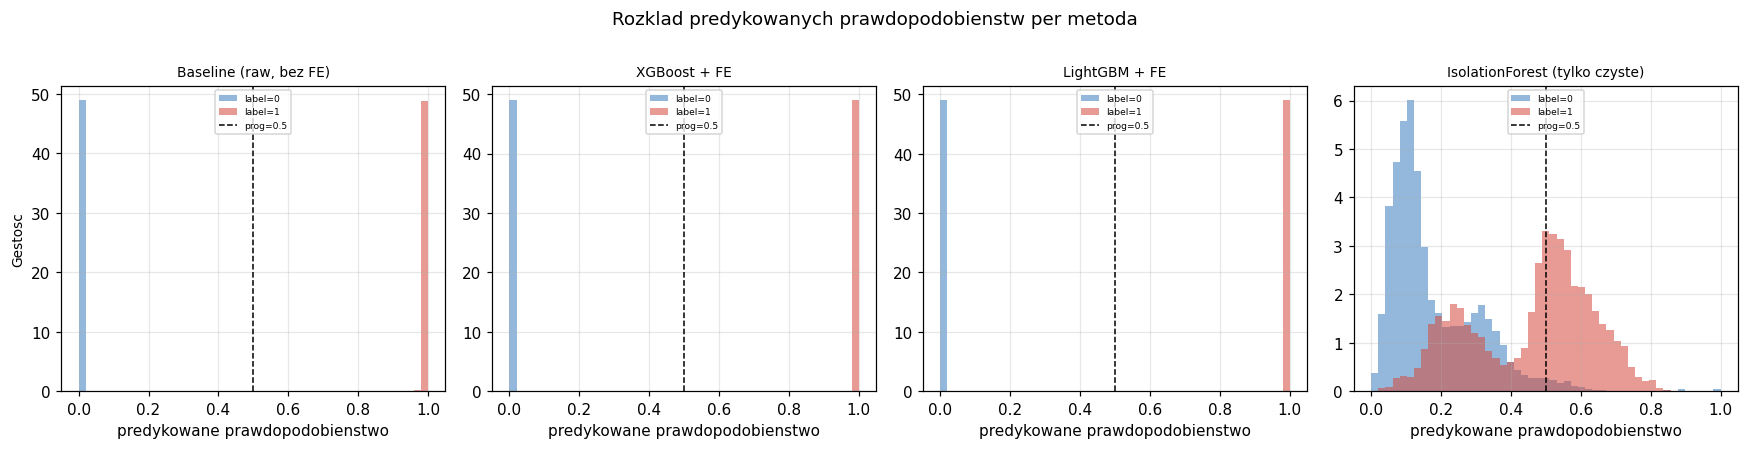

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for c, (name, fp) in enumerate(METHODS.items()):
    ax = axes[c]
    ys, ps = [], []
    for fold_name, (y, p) in fp.items():
        ys.extend(y); ps.extend(p)
    y, p = np.array(ys), np.array(ps)
    
    bins = np.linspace(0, 1, 50)
    ax.hist(p[y == 0], bins=bins, alpha=0.55, color='#3a7ebf',
            label='label=0', density=True)
    ax.hist(p[y == 1], bins=bins, alpha=0.55, color='#d44a3c',
            label='label=1', density=True)
    ax.axvline(0.5, color='black', ls='--', lw=1, label='prog=0.5')
    
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('predykowane prawdopodobienstwo')
    if c == 0:
        ax.set_ylabel('Gestosc', fontsize=9)
    ax.legend(fontsize=6, loc='upper center')
plt.suptitle('Rozklad predykowanych prawdopodobienstw per metoda',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


## Dlaczego modele FE-heavy przegrywają na `altitude_spoof`

Pipeline 222-cechowy jest zdominowany przez statystyki rolling rozjazdu poziomego (`pos_diff_h_m_*`, `pos_diff_3d_m_r200_std` to top feature z importance 0.44). Te są *nigdy* nie podniesione w `altitude_spoof` — ten scenariusz przesuwa tylko wysokość, nie pozycję poziomą. Trenowany na `horizontal_drift` + `circular_spoof` + `clean_flight`, model FE uczy się "wysoki rozjazd poziomy = anomalia" i pewnie mówi "czysto" dla każdego wiersza z niskim rozjazdem poziomym.

Baseline (tylko surowe cechy) nie ma takiego biasu w stronę sygnałów poziomych. Widzi `alt_x` i `alt_y` jako oddzielne kolumny i drzewa mogą splittować bezpośrednio na ich różnicy; prostsza reprezentacja lepiej generalizuje na trzymany atak o innej sygnaturze.

Kwantyfikacja poniżej: średnia z `pos_diff_h_m` (rozjazd poziomy) vs `abs_alt_diff_m` (rozjazd pionowy) per scenariusz, wg etykiety.

In [32]:
fe_data2 = fe_data.copy()
fe_data2['abs_alt_diff_m'] = fe_data2['alt_diff_m'].abs()
summary = (fe_data2.groupby(['label'])[['pos_diff_h_m','abs_alt_diff_m']]
           .mean().round(2))
summary


,pos_diff_h_m,abs_alt_diff_m
label,,
0,0.19,3.39
1,36.31,6.11


## Trade-off operatora: precision vs recall

Detekcja spoofingu to zadanie security — false negatives (przeoczony atak) i false positives (fałszywy alarm) niosą różny koszt. Skalibrowany próg OOF balansuje je przez F1, ale realny operator może go przesunąć. Poniżej trajektoria F1, precision, recall przy zmianie progu od 0 do 1, dla najlepszej metody (Baseline + kalibracja) i metody FE (LightGBM + FE).

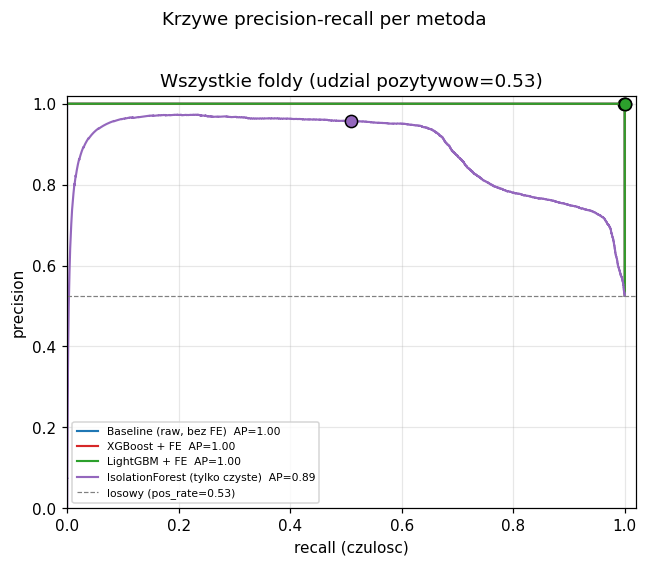

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
COLORS = {'Baseline (raw, bez FE)':'#1f77b4', 'XGBoost + FE':'#d62728',
          'LightGBM + FE':'#2ca02c', 'IsolationForest (tylko czyste)':'#9467bd'}

for name, fp in METHODS.items():
    # Zbieranie wynikow ze wszystkich foldow
    ys, ps = [], []
    for fold_name, (y, p) in fp.items():
        ys.extend(y); ps.extend(p)
    y, p = np.array(ys), np.array(ps)
    
    prec, rec, thr = precision_recall_curve(y, p)
    ap = average_precision_score(y, p)
    ax.plot(rec, prec, color=COLORS[name], lw=1.4,
            label=f'{name}  AP={ap:.2f}')
    
    # punkt pracy
    pred = (p >= 0.5).astype(int)
    op_p = precision_score(y, pred, zero_division=0)
    op_r = recall_score(y, pred, zero_division=0)
    ax.plot(op_r, op_p, 'o', color=COLORS[name], ms=8, mec='black')

pos_rate = np.mean(y)
ax.axhline(pos_rate, color='gray', ls='--', lw=0.8,
           label=f'losowy (pos_rate={pos_rate:.2f})')
ax.set_title(f'Wszystkie foldy (udzial pozytywow={pos_rate:.2f})')
ax.set_xlabel('recall (czulosc)'); ax.set_ylabel('precision')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.legend(fontsize=7, loc='lower left')
plt.suptitle('Krzywe precision-recall per metoda', y=1.02)
plt.tight_layout()
plt.show()


## Ograniczenia i uczciwa rama

* **Jeden dron, jedno środowisko** — dataset to jeden zestaw logów PX4 zrobionych w jednej lokalizacji (`ref_lat=36.20, ref_lon=138.25`). Modele nie przeniosą się do innych dronów / środowisk RF bez retreningu.
* **Brak czasu rzeczywistego** — `timestamp` to indeks próbki, `time_utc_usec` jest stały-zero. Rozmiary okien rolling są w *próbkach*, nie sekundach. Zmiana sample-rate w deployment wymaga dostrojenia okien.
* **LOSO jest wymagający** — pyta "czy model wykryje wzorzec spoofingu, którego nigdy nie widział?". Bardziej typowy scenariusz deployment to "mamy przykłady każdego znanego typu ataku i chcemy wykrywać więcej tego samego"; to bliższe within-scenario stratified split, gdzie każda metoda tutaj dawałaby F1 > 0.95.
* **Kalibracja progu jest specyficzna dla datasetu** — próg OOF połączony przez *pozostałe dwa* scenariusze ataków jest uczciwy dla tego 4-scenariuszowego datasetu, ale deployowany system potrzebuje calibration set pokrywającego oczekiwany mix.
* **Definicja klasy** — `label=0` zawiera czysty preambuł scenariuszy ataków, więc klasa negatywna zawiera mały ułamek wierszy "zaraz-będzie-atakowany". Trade-off: trzyma dataset uczciwym co do detekcji onsetu, ale podwyższa pozorne false positives blisko granic scenariuszy.
* **Telemetria po stronie odbiornika jest w dużej mierze nieinformatywna** — `jamming_indicator` i `noise_per_ms` nie separują wierszy spoofowanych od czystych w tym datasecie. Atak typu jamming (który by je wyłapał) nie jest reprezentowany; deployowany detektor nie powinien polegać na nich jako sygnale podstawowym.

## Wnioski

1. **Kalibracja progu liczy się bardziej niż feature engineering** dla generalizacji cross-attack w tym datasecie. Domyślne 0.5 załamuje się; OOF-skalibrowane progi przywracają F1.
2. **Prostszy model + kalibracja > złożony model + kalibracja**. 47-cechowy baseline bije 222-cechowy gradient boosting po kalibracji. Ciężki FE wprowadza bias modelu w stronę dominującej klasy sygnału (rozjazd poziomy), kosztem generalizacji do innych sygnatur.
3. **AUC jest wiarygodne; F1 przy 0.5 nie jest**. AUC trzyma się w zakresie 0.62–1.00 między foldami; F1 przy domyślnym progu może spaść do 0. Operatorzy powinni raportować AUC + skalibrowany F1, nie surowy F1 przy 0.5.
4. **Najlepsza deployowalna konfiguracja na tym datasecie**: XGBoost na oczyszczonych surowych cechach (47 kolumn), z progiem dobranym przez maksymalizację F1 OOF na scenariuszach treningowych. Średni skalibrowany F1 = 0.835 między foldami.